# Assignment 1: Classical Machine Learning
### Gesture Phase Segmentation

# Table of Contents

| No. | Section                     |
|-----|-----------------------------|
| 1   | Group Details               |
| 2   | Load Modules                |
| 3   | Load Data                   |
| 4   | Evaluate Function           |
| 5   | Training                    |
| 6   | Evaluation                  |
| 7   | References                  |
| 8   | Appendix I                  |

# Group number: 11

| Name                   | KU-ID     |
|------------------------|-----------|
| Lalith Aditya Devaraj  | K2551111  |
| Raja Mathangi Sundar   | K2542487  |
| Shalini Manikkavasagam | K2551032  |
| Threya Reddy Tummeti   | K2557789  |

# Load Modules

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load Data

In [3]:
dataset = fetch_openml(data_id=4538, as_frame=False)
X, y = dataset.data, dataset.target
CLASSES = np.unique(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
y_test_bin = label_binarize(y_test, classes=CLASSES)
print("=" * 55)
print("DATASET SUMMARY")
print("=" * 55)
print("Dataset name   : GesturePhaseSegmentationProcessed")
print(f'Samples: {X.shape[0]}  Features: {X.shape[1]}  Classes: {list(CLASSES)}')
print(f'Train: {len(X_train)}  Test: {len(X_test)}')
classes_u, counts = np.unique(y, return_counts=True)
print(pd.DataFrame({'Class': classes_u, 'Count': counts, '%': (counts/len(y)*100).round(1)}).to_string(index=False))

DATASET SUMMARY
Dataset name   : GesturePhaseSegmentationProcessed
Samples: 9873  Features: 32  Classes: ['D', 'H', 'P', 'R', 'S']
Train: 6911  Test: 2962
Class  Count    %
    D   2741 27.8
    H    998 10.1
    P   2097 21.2
    R   1087 11.0
    S   2950 29.9


# Shared Evaluation Function — `evaluate()`

To avoid repeating the same evaluation logic across all eight classification models, a single reusable function `evaluate()` is defined here and called once per model in the **Evaluate All Models** block.

**What `evaluate(name, y_true, y_pred, y_prob)` does:**

| Step | Description |
|------|-------------|
| Balanced Accuracy | Computes mean per-class recall — the primary metric, preferred over raw accuracy due to class imbalance |
| Macro AUC | Computes One-vs-Rest ROC AUC averaged equally across all 5 gesture classes |
| Micro AUC | Computes OvR ROC AUC aggregated across all samples, weighted by class frequency |
| Classification Report | Prints per-class precision, recall, F1-score and support |
| Confusion Matrix | Plots a colour-coded matrix showing correct vs incorrect predictions per class |
| Per-class ROC curves | Computes and stores individual OvR ROC curves for each of the 5 gesture phases |
| Macro-average ROC curve | Interpolates per-class curves onto a common FPR grid and averages the TPR |
| Micro-average ROC curve | Flattens all class scores and labels into a single binary problem |
| Results storage | Saves all scalar metrics into `all_results` and all curve data into `all_roc_data` |

In [4]:
all_results, all_roc_data = {}, {}

def print_top5(search):
    res = sorted(zip(search.cv_results_['rank_test_score'],
                     search.cv_results_['mean_test_score'],
                     search.cv_results_['params']), key=lambda x: x[0])
    print("\nTop 5 (by CV Balanced Accuracy):")
    for rank, score, p in res[:5]:
        print(f"  Rank {rank} | {score:.4f} | " +
              ", ".join(f"{k}={v}" for k, v in p.items()))

def evaluate(name, y_true, y_pred, y_prob):
    bal_acc   = balanced_accuracy_score(y_true, y_pred)
    macro_auc = roc_auc_score(y_test_bin, y_prob, average='macro', multi_class='ovr')
    micro_auc = roc_auc_score(y_test_bin, y_prob, average='micro')

    print(f'\n=== Evaluation Metrics: {name} ===\n')
    print(f'Balanced Accuracy: {bal_acc:.4f}  Macro AUC: {macro_auc:.4f}  Micro AUC: {micro_auc:.4f}')
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred, labels=CLASSES), display_labels=CLASSES).plot(cmap='Purples')
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout(); plt.show()

    # Per-class OvR ROC curves
    fpr, tpr, roc_auc_vals = {}, {}, {}
    for i, cls in enumerate(CLASSES):
        fpr[cls], tpr[cls], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc_vals[cls] = auc(fpr[cls], tpr[cls])

    # Macro-average: interpolate per-class curves onto common FPR grid, then average
    common_fpr = np.linspace(0, 1, 1000)
    mean_tpr = np.mean([np.interp(common_fpr, fpr[cls], tpr[cls]) for cls in CLASSES], axis=0)
    mean_tpr[-1] = 1.0
    fpr['macro'], tpr['macro'] = common_fpr, mean_tpr
    # Micro-average: flatten all classes into one binary problem
    fpr['micro'], tpr['micro'], _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    fpr['micro'][-1] = 1.0
    tpr['micro'][-1] = 1.0

    all_results[name] = {'balanced_accuracy': bal_acc, 'macro_auc': macro_auc, 'micro_auc': micro_auc}
    all_roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc_vals}

# Training

## Tree Ensemble Models

All five tree-based ensemble models are trained in this single block. Each uses cross-validated hyperparameter search with `balanced_accuracy` as the scoring metric. `RANDOM_STATE = 42` is fixed throughout to ensure reproducibility.

| Model | Search Strategy | CV Folds | Iterations |
|-------|----------------|----------|------------|
| Random Forest | RandomizedSearchCV | 5 | 40 |
| Extra Trees | RandomizedSearchCV | 5 | 40 |
| Gradient Boosting | GridSearchCV | 5 | 108 combos |
| XGBoost | GridSearchCV | 5 | 324 combos |
| LightGBM | RandomizedSearchCV | 5 | 40 |

In [5]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("=== Hyperparameter Tuning: Random Forest ===\n")
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'),
    {'n_estimators': [50, 100, 200, 300, 500], 'max_depth': [None, 5, 10, 20, 30],
     'min_samples_split': [2, 5, 10, 20], 'min_samples_leaf': [1, 2, 4, 8],
     'max_features': ['sqrt', 'log2', 0.3, 0.5]},
    n_iter=40, cv=cv5, scoring='balanced_accuracy',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
rf_search.fit(X_train, y_train)
print_top5(rf_search)

print("\n=== Hyperparameter Tuning: Extra Trees ===\n")
et_search = RandomizedSearchCV(
    ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'),
    {'n_estimators': [50, 100, 200, 300, 500], 'max_depth': [None, 5, 10, 20, 30],
     'min_samples_split': [2, 5, 10, 20], 'min_samples_leaf': [1, 2, 4, 8],
     'max_features': ['sqrt', 'log2', 0.3, 0.5]},
    n_iter=40, cv=cv5, scoring='balanced_accuracy',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
et_search.fit(X_train, y_train)
print_top5(et_search)

print("\n=== Hyperparameter Tuning: Gradient Boosting ===\n")
gb_search = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.05, 0.1, 0.2],
     'max_depth': [3, 5, 7], 'subsample': [0.6, 0.8, 1.0]},
    cv=cv5, scoring='balanced_accuracy', n_jobs=-1, verbose=1
)
gb_search.fit(X_train, y_train)
print_top5(gb_search)

print("\n=== Hyperparameter Tuning: XGBoost ===\n")
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
xgb_search = GridSearchCV(
    XGBClassifier(objective='multi:softprob', use_label_encoder=False,
                  eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1),
    {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.05, 0.1, 0.2],
     'max_depth': [3, 5, 7], 'subsample': [0.6, 0.8, 1.0],
     'colsample_bytree': [0.6, 0.8, 1.0]},
    cv=cv5, scoring='balanced_accuracy', n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train_enc)
print_top5(xgb_search)

print("\n=== Hyperparameter Tuning: LightGBM ===\n")
lgbm_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=1, class_weight='balanced'),
    {'n_estimators': [50, 100, 200, 300, 500], 'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
     'num_leaves': [15, 31, 63, 127], 'max_depth': [-1, 3, 5, 7, 10],
     'min_child_samples': [10, 20, 30, 50],
     'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], 'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]},
    n_iter=40, cv=cv5, scoring='balanced_accuracy',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
lgbm_search.fit(X_train, y_train)
print_top5(lgbm_search)

print("\n✓ All tree ensemble models trained.")

=== Hyperparameter Tuning: Random Forest ===

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Top 5 (by CV Balanced Accuracy):
  Rank 1 | 0.5934 | n_estimators=500, min_samples_split=2, min_samples_leaf=2, max_features=0.5, max_depth=30
  Rank 2 | 0.5922 | n_estimators=300, min_samples_split=10, min_samples_leaf=4, max_features=0.5, max_depth=20
  Rank 3 | 0.5915 | n_estimators=500, min_samples_split=5, min_samples_leaf=4, max_features=0.5, max_depth=30
  Rank 3 | 0.5915 | n_estimators=500, min_samples_split=5, min_samples_leaf=4, max_features=0.5, max_depth=None
  Rank 5 | 0.5890 | n_estimators=300, min_samples_split=5, min_samples_leaf=2, max_features=0.5, max_depth=30

=== Hyperparameter Tuning: Extra Trees ===

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Top 5 (by CV Balanced Accuracy):
  Rank 1 | 0.6233 | n_estimators=300, min_samples_split=5, min_samples_leaf=2, max_features=0.5, max_depth=30
  Rank 2 | 0.6188 | n_estimators=500, min_samples_spli

## KNN, SVM, MLP

| Model                        | Search Strategy                      | CV Folds | Search Space |
|------------------------------|--------------------------------------|----------|---------------|
| K-Nearest Neighbours (KNN)   | GridSearchCV (OneVsRest)             | 5        | 54 combos     |
| Support Vector Machine (RBF) | GridSearchCV (OneVsRest)             | 3        | 64 combos     |
| Multi-Layer Perceptron (MLP) | RandomizedSearchCV (Pipeline+Scaler) | 3        | 30 iterations |

In [6]:
print("=== Hyperparameter Tuning: KNN ===\n")
knn_search = GridSearchCV(
    OneVsRestClassifier(KNeighborsClassifier(n_jobs=-1)),
    {'estimator__n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21, 31],
     'estimator__weights': ['uniform', 'distance'],
     'estimator__metric': ['euclidean', 'manhattan', 'minkowski']},
    cv=5, scoring='balanced_accuracy', n_jobs=-1, verbose=1
)
knn_search.fit(X_train, y_train)
print_top5(knn_search)

print("\n=== Hyperparameter Tuning: SVM (RBF) ===\n")
svm_search = GridSearchCV(
    OneVsRestClassifier(SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE, class_weight='balanced')),
    {'estimator__C': [0.01, 0.1, 0.5, 1, 5, 10, 50, 100],
     'estimator__gamma': ['scale', 'auto', 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]},
    cv=3, scoring='balanced_accuracy', n_jobs=-1, verbose=1
)
svm_search.fit(X_train, y_train)
print_top5(svm_search)

print("\n=== Hyperparameter Tuning: MLP ===\n")
mlp_search = RandomizedSearchCV(
    Pipeline([('scaler', StandardScaler()),
              ('clf', MLPClassifier(max_iter=500, random_state=RANDOM_STATE))]),
    {'clf__hidden_layer_sizes': [(64,), (128,), (256,), (64, 64), (128, 64),
                                  (128, 128), (256, 128), (64, 64, 32)],
     'clf__activation': ['relu', 'tanh'],
     'clf__alpha': [1e-5, 1e-4, 1e-3, 0.01, 0.1],
     'clf__learning_rate': ['constant', 'adaptive']},
    n_iter=30, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='balanced_accuracy', n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
mlp_search.fit(X_train, y_train)
print_top5(mlp_search)

print("\n✓ All other models trained.")

models = {
    'Random Forest': rf_search, 'Extra Trees': et_search,
    'Gradient Boosting': gb_search, 'XGBoost': xgb_search,
    'LightGBM': lgbm_search, 'KNN': knn_search,
    'SVM (RBF)': svm_search, 'MLP': mlp_search,
}

=== Hyperparameter Tuning: KNN ===

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Top 5 (by CV Balanced Accuracy):
  Rank 1 | 0.6329 | estimator__metric=manhattan, estimator__n_neighbors=1, estimator__weights=uniform
  Rank 1 | 0.6329 | estimator__metric=manhattan, estimator__n_neighbors=1, estimator__weights=distance
  Rank 3 | 0.6107 | estimator__metric=euclidean, estimator__n_neighbors=1, estimator__weights=uniform
  Rank 3 | 0.6107 | estimator__metric=euclidean, estimator__n_neighbors=1, estimator__weights=distance
  Rank 3 | 0.6107 | estimator__metric=minkowski, estimator__n_neighbors=1, estimator__weights=uniform

=== Hyperparameter Tuning: SVM (RBF) ===

Fitting 3 folds for each of 64 candidates, totalling 192 fits

Top 5 (by CV Balanced Accuracy):
  Rank 1 | 0.5207 | estimator__C=50, estimator__gamma=scale
  Rank 2 | 0.5199 | estimator__C=100, estimator__gamma=scale
  Rank 3 | 0.5152 | estimator__C=10, estimator__gamma=scale
  Rank 4 | 0.5115 | estimator__C=5, 

# Evaluation

All 8 trained models are evaluated here in a single block using the shared `evaluate()` function. This ensures identical metric computation across every model and keeps the training and evaluation phases clearly separated.


=== Evaluation Metrics: Random Forest ===

Balanced Accuracy: 0.6182  Macro AUC: 0.8932  Micro AUC: 0.9046
              precision    recall  f1-score   support

           D       0.69      0.87      0.77       822
           H       0.74      0.45      0.56       300
           P       0.67      0.52      0.58       629
           R       0.61      0.53      0.56       326
           S       0.66      0.72      0.69       885

    accuracy                           0.67      2962
   macro avg       0.67      0.62      0.63      2962
weighted avg       0.67      0.67      0.66      2962



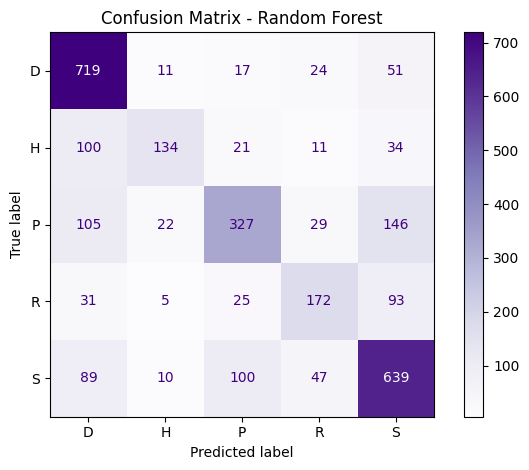


=== Evaluation Metrics: Extra Trees ===

Balanced Accuracy: 0.6547  Macro AUC: 0.9035  Micro AUC: 0.9131
              precision    recall  f1-score   support

           D       0.70      0.87      0.77       822
           H       0.80      0.53      0.64       300
           P       0.68      0.56      0.62       629
           R       0.65      0.59      0.62       326
           S       0.69      0.72      0.71       885

    accuracy                           0.70      2962
   macro avg       0.70      0.65      0.67      2962
weighted avg       0.70      0.70      0.69      2962



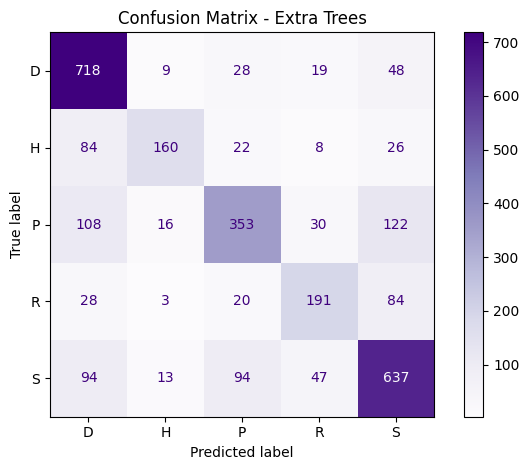


=== Evaluation Metrics: Gradient Boosting ===

Balanced Accuracy: 0.6109  Macro AUC: 0.8920  Micro AUC: 0.9044
              precision    recall  f1-score   support

           D       0.72      0.86      0.78       822
           H       0.68      0.45      0.54       300
           P       0.65      0.56      0.60       629
           R       0.66      0.44      0.52       326
           S       0.65      0.75      0.70       885

    accuracy                           0.67      2962
   macro avg       0.67      0.61      0.63      2962
weighted avg       0.67      0.67      0.67      2962



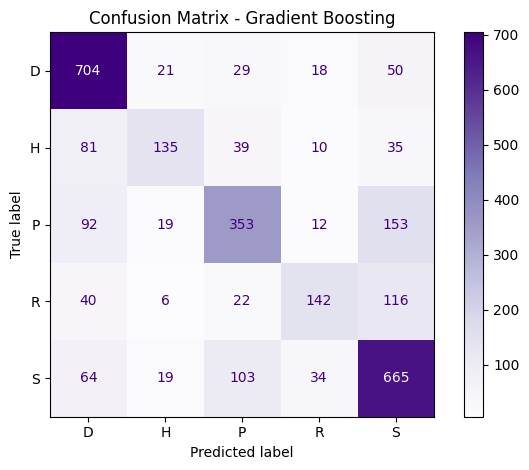


=== Evaluation Metrics: XGBoost ===

Balanced Accuracy: 0.6395  Macro AUC: 0.9047  Micro AUC: 0.9156
              precision    recall  f1-score   support

           D       0.73      0.86      0.79       822
           H       0.74      0.50      0.60       300
           P       0.68      0.57      0.62       629
           R       0.67      0.48      0.56       326
           S       0.67      0.79      0.72       885

    accuracy                           0.70      2962
   macro avg       0.70      0.64      0.66      2962
weighted avg       0.70      0.70      0.69      2962



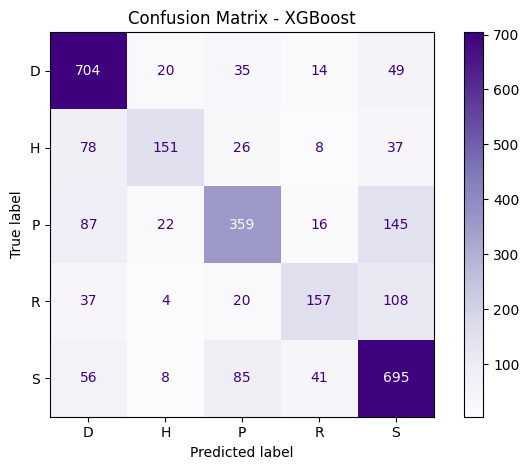


=== Evaluation Metrics: LightGBM ===

Balanced Accuracy: 0.6694  Macro AUC: 0.9138  Micro AUC: 0.9237
              precision    recall  f1-score   support

           D       0.76      0.87      0.81       822
           H       0.69      0.58      0.63       300
           P       0.70      0.59      0.64       629
           R       0.63      0.53      0.57       326
           S       0.71      0.77      0.74       885

    accuracy                           0.72      2962
   macro avg       0.70      0.67      0.68      2962
weighted avg       0.71      0.72      0.71      2962



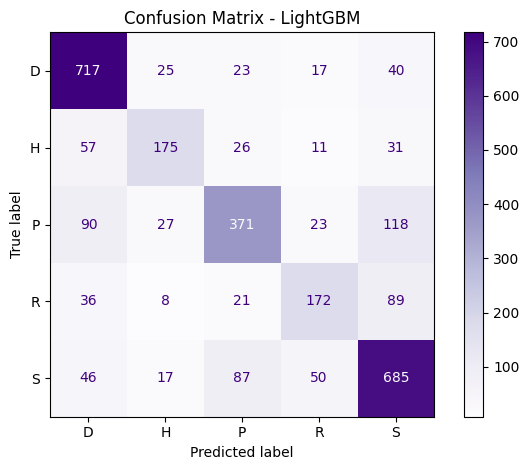


=== Evaluation Metrics: KNN ===

Balanced Accuracy: 0.6719  Macro AUC: 0.7960  Micro AUC: 0.8071
              precision    recall  f1-score   support

           D       0.74      0.80      0.77       822
           H       0.63      0.65      0.64       300
           P       0.65      0.61      0.63       629
           R       0.59      0.60      0.60       326
           S       0.74      0.69      0.71       885

    accuracy                           0.69      2962
   macro avg       0.67      0.67      0.67      2962
weighted avg       0.69      0.69      0.69      2962



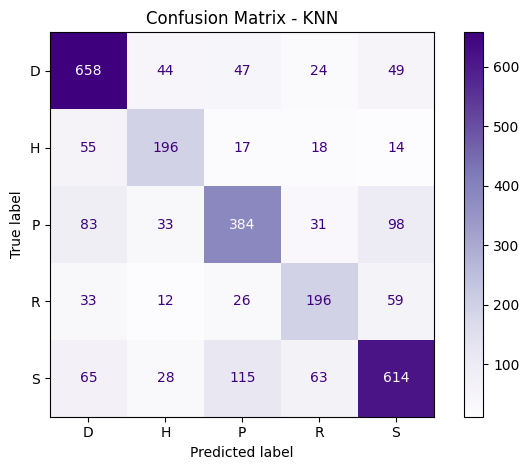


=== Evaluation Metrics: SVM (RBF) ===

Balanced Accuracy: 0.5461  Macro AUC: 0.8224  Micro AUC: 0.8446
              precision    recall  f1-score   support

           D       0.60      0.72      0.65       822
           H       0.34      0.51      0.41       300
           P       0.56      0.48      0.52       629
           R       0.48      0.52      0.50       326
           S       0.70      0.51      0.59       885

    accuracy                           0.56      2962
   macro avg       0.54      0.55      0.53      2962
weighted avg       0.58      0.56      0.56      2962



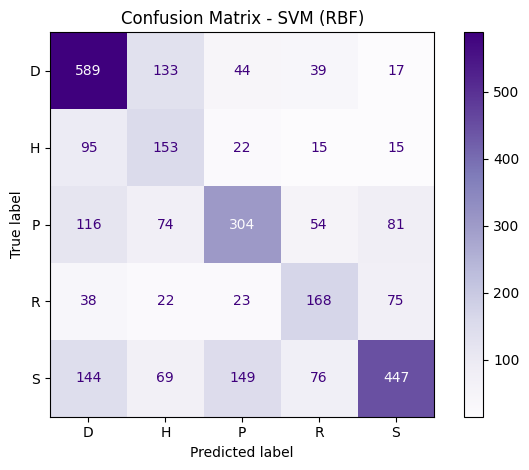


=== Evaluation Metrics: MLP ===

Balanced Accuracy: 0.5677  Macro AUC: 0.8123  Micro AUC: 0.8298
              precision    recall  f1-score   support

           D       0.68      0.76      0.72       822
           H       0.52      0.49      0.51       300
           P       0.52      0.51      0.51       629
           R       0.50      0.49      0.49       326
           S       0.64      0.59      0.61       885

    accuracy                           0.60      2962
   macro avg       0.57      0.57      0.57      2962
weighted avg       0.60      0.60      0.60      2962



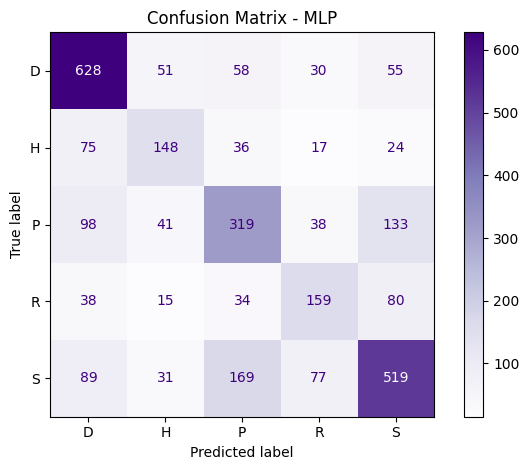

In [7]:
for name, search in models.items():
    y_pred = search.best_estimator_.predict(X_test)
    if name == 'XGBoost':
        y_pred = le.inverse_transform(y_pred)
# Evaluate function Has been defined in the Start of the section
    evaluate(name, y_test, y_pred, search.best_estimator_.predict_proba(X_test))

## Comparison Of all the 8 Models

In [13]:
summary = pd.DataFrame(all_results).T
summary.columns = ['Bal. Acc', 'Macro AUC', 'Micro AUC']
summary = summary.sort_values('Macro AUC', ascending=False)
print(summary.round(4).to_string())

                   Bal. Acc  Macro AUC  Micro AUC
LightGBM             0.6694     0.9138     0.9237
XGBoost              0.6395     0.9047     0.9156
Extra Trees          0.6547     0.9035     0.9131
Random Forest        0.6182     0.8932     0.9046
Gradient Boosting    0.6109     0.8920     0.9044
SVM (RBF)            0.5461     0.8224     0.8446
MLP                  0.5677     0.8123     0.8298
KNN                  0.6719     0.7960     0.8071


## ROC Comparison per Class

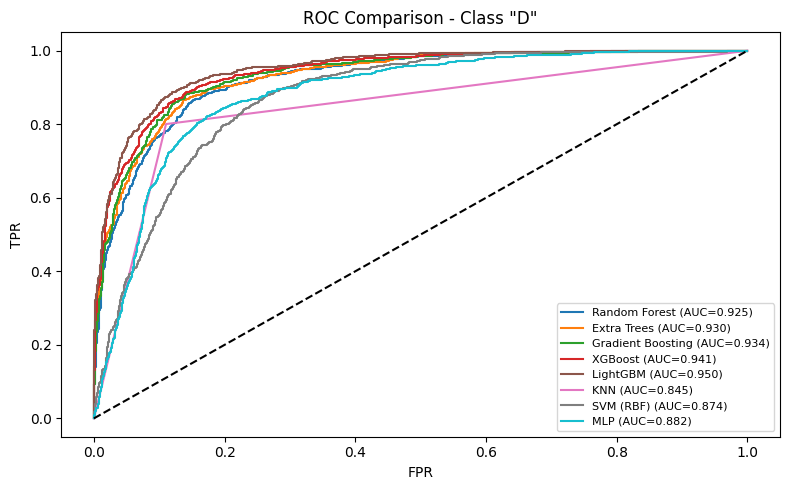

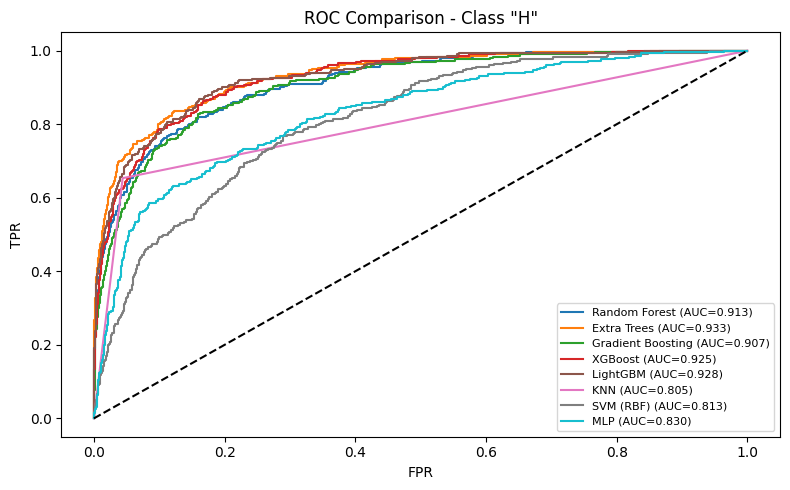

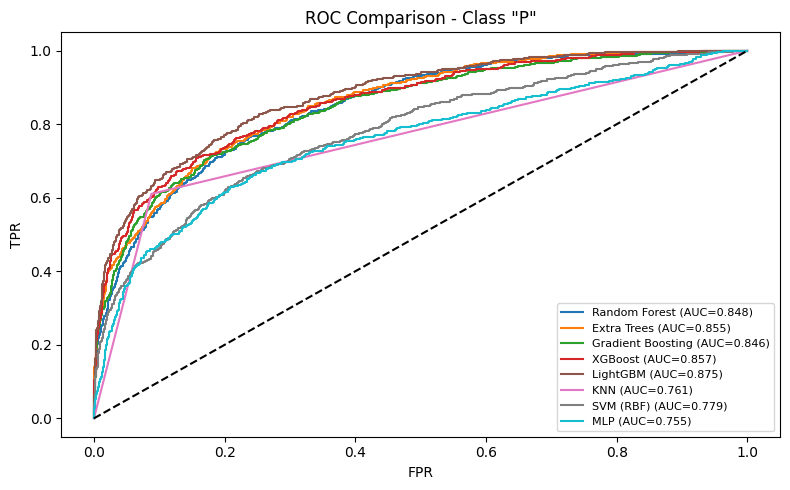

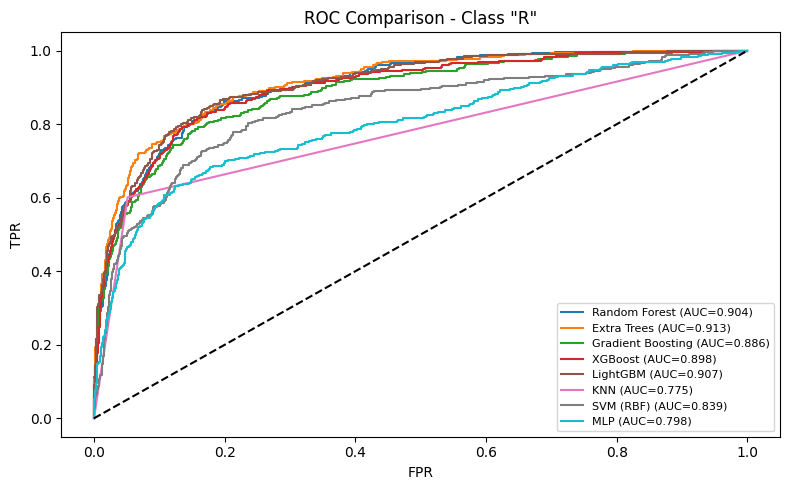

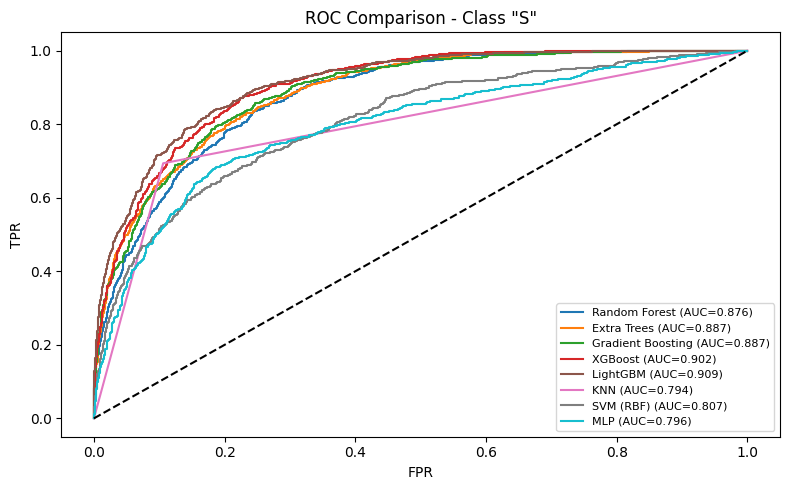

In [11]:
plot_colors = plt.cm.tab10(np.linspace(0, 0.9, len(all_roc_data)))
for cls in CLASSES:
    fig, ax = plt.subplots(figsize=(8, 5))
    for (name, data), color in zip(all_roc_data.items(), plot_colors):
        ax.plot(data['fpr'][cls], data['tpr'][cls], color=color,
                label=f'{name} (AUC={data["auc"][cls]:.3f})')
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'ROC Comparison - Class "{cls}"')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout(); plt.show()

## Macro-average OvR ROC:

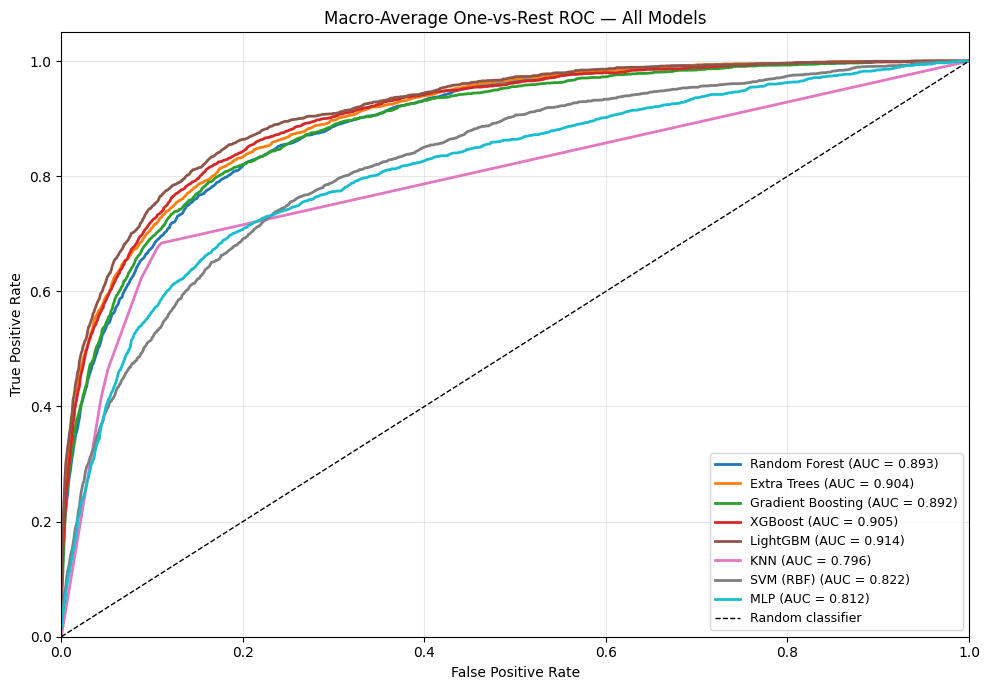

In [9]:
# Macro and Micro average OvR ROC
def plot_avg_roc(roc_type, title):
    fig, ax = plt.subplots(figsize=(10, 7))
    for (name, data), color in zip(all_roc_data.items(), plot_colors):
        auc_val = all_results[name][f'{roc_type}_auc']
        ax.plot(data['fpr'][roc_type], data['tpr'][roc_type], color=color, lw=2,
                label=f'{name} (AUC = {auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    ax.set(xlim=[0, 1], ylim=[0, 1.05], xlabel='False Positive Rate',
           ylabel='True Positive Rate', title=title)
    ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_avg_roc('macro', 'Macro-Average One-vs-Rest ROC — All Models')

## Micro-average OvR ROC:

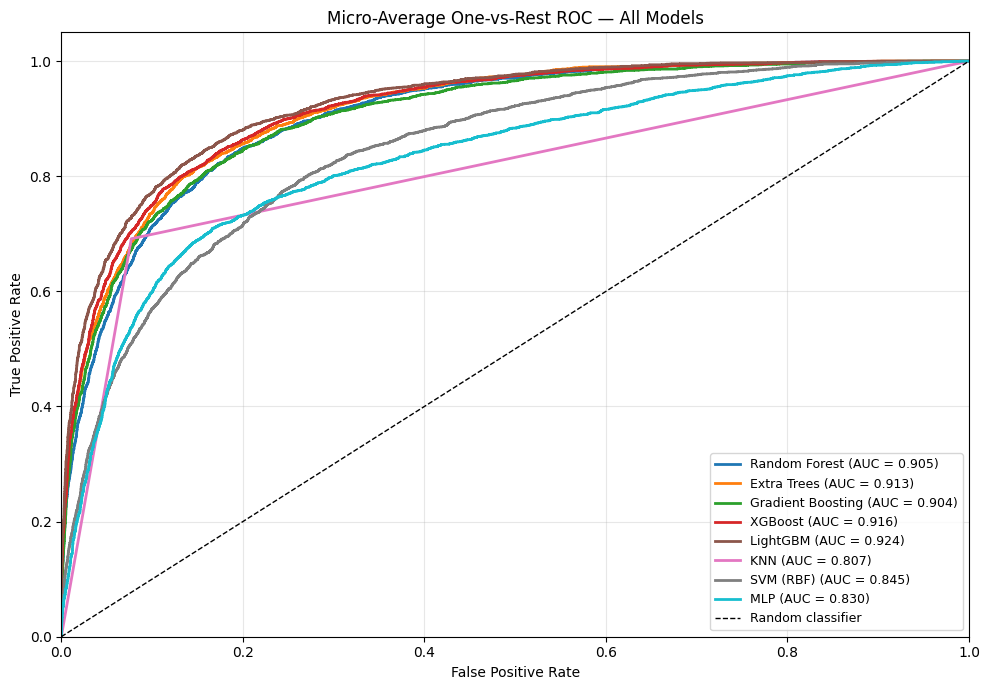

In [10]:
plot_avg_roc('micro', 'Micro-Average One-vs-Rest ROC — All Models')

# References

### 1. K-Nearest Neighbours (KNN)
- **Theory:** Cover, T. & Hart, P. (1967). *Nearest Neighbor Pattern Classification.* IEEE Transactions on Information Theory.
- **Implementation:** scikit-learn. *KNeighborsClassifier API.* https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

### 2. Gradient Boosting
- **Theory:** Friedman, J. H. (2001). *Greedy Function Approximation: A Gradient Boosting Machine.* Annals of Statistics.
- **Implementation:** scikit-learn. *GradientBoostingClassifier API.* https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

### 3. XGBoost
- **Theory:** Chen, T. & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System.* KDD 2016. https://arxiv.org/abs/1603.02754
- **Implementation:** XGBoost Developers. *XGBoost Python API.* https://xgboost.readthedocs.io/en/stable/python/python_api.html

### 4. Random Forest
- **Theory:** Breiman, L. (2001). *Random Forests.* Machine Learning, 45(1), 5–32.
- **Implementation:** scikit-learn. *RandomForestClassifier API.* https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

### 5. Extra Trees
- **Theory:** Geurts, P., Ernst, D. & Wehenkel, L. (2006). *Extremely Randomized Trees.* Machine Learning, 63(1), 3–42.
- **Implementation:** scikit-learn. *ExtraTreesClassifier API.* https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html

### 6. Multi-Layer Perceptron (MLP)
- **Theory:** Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning.* MIT Press.
- **Implementation:** scikit-learn. *MLPClassifier API.* https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

### 7. LightGBM
- **Theory:** Ke, G. et al. (2017). *LightGBM: A Highly Efficient Gradient Boosting Decision Tree.* NeurIPS.
- **Implementation:** LightGBM Developers. *LGBMClassifier API.* https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.LGBMClassifier.html

### 8. Support Vector Machine (SVM)
- **Theory:** Cortes, C. & Vapnik, V. (1995). *Support-Vector Networks.* Machine Learning, 20(3), 273–297.
- **Implementation:** scikit-learn. *SVC API.* https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html

### 9. Evaluation Metrics References
- **Balanced Accuracy:** Brodersen, K. H. et al. (2010). *The Balanced Accuracy and Its Posterior Distribution.* ICPR. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html
- **ROC AUC (Macro & Micro):** Fawcett, T. (2006). *An Introduction to ROC Analysis.* Pattern Recognition Letters, 27(8), 861–874. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html

# APPENDIX I: Use of Generative AI

· This submission is my/our own independent work and all sources used in the submission are referenced. Generative AI was NOT USED for this submission.